# RoadSafe India — Accident Rate Analysis

## Objective

This notebook combines 2024 State/UT-level reported road accidents with
2024 projected population to calculate:

**Reported road accidents per 100,000 projected population**

This metric provides a population-normalized comparison of accident burden
across States/UTs.

It should not be interpreted as the true underlying road-accident risk,
because population does not measure actual road-traffic exposure.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
accident_path = (
    "../data/processed/"
    "state_wise_road_accidents_2020_2024_cleaned.csv"
)

population_path = (
    "../data/processed/"
    "state_population_2024.csv"
)

accident_df = pd.read_csv(accident_path)
population_df = pd.read_csv(population_path)

print("Accident data:", accident_df.shape)
print("Population data:", population_df.shape)

Accident data: (39, 14)
Population data: (37, 3)


In [16]:
accident_2024 = accident_df[
    ["state", "2024_accidents"]
].copy()

population_2024 = population_df[
    ["state", "population_2024"]
].copy()

In [17]:
# Remove missing State/UT or missing accident values
accident_2024 = accident_2024[
    accident_2024["state"].notna() &
    accident_2024["2024_accidents"].notna()
].copy()

# Remove aggregate rows such as Total (All India)
accident_2024 = accident_2024[
    ~accident_2024["state"].str.contains(
        "total|india",
        case=False,
        na=False
    )
].copy()

print("Accident rows:", len(accident_2024))

Accident rows: 36


In [18]:
accident_2024["state"] = (
    accident_2024["state"]
    .astype("string")
    .str.strip()
)

population_2024["state"] = (
    population_2024["state"]
    .astype("string")
    .str.strip()
)

# Align names between datasets
accident_2024["state"] = accident_2024["state"].replace({
    "Delhi": "N.C.T of Delhi",
    "J & K #": "Jammu & Kashmir"
})

In [19]:
combined_names = [
    "Dadra & Nagar Haveli",
    "Daman & Diu"
]

combined_population = population_2024.loc[
    population_2024["state"].isin(combined_names),
    "population_2024"
].sum()

print(
    "Combined population:",
    f"{combined_population:,.0f}"
)

# Remove the two original entries
population_2024 = population_2024[
    ~population_2024["state"].isin(combined_names)
].copy()

# Add exactly ONE combined entry
population_2024 = pd.concat(
    [
        population_2024,
        pd.DataFrame({
            "state": [
                "Dadra & Nagar Haveli and Daman & Diu"
            ],
            "population_2024": [
                combined_population
            ]
        })
    ],
    ignore_index=True
)

Combined population: 1,356,000


In [20]:
accident_states = set(
    accident_2024["state"].dropna()
)

population_states = set(
    population_2024["state"].dropna()
)

accident_only = sorted(
    accident_states - population_states
)

population_only = sorted(
    population_states - accident_states
)

print("States only in accident data:")
print(accident_only)

print("\nStates only in population data:")
print(population_only)

print("\nAccident rows:", len(accident_2024))
print("Accident unique states:", accident_2024["state"].nunique())

print("\nPopulation rows:", len(population_2024))
print("Population unique states:", population_2024["state"].nunique())

States only in accident data:
[]

States only in population data:
[]

Accident rows: 36
Accident unique states: 36

Population rows: 36
Population unique states: 36


In [21]:
if accident_only or population_only:
    raise ValueError(
        "State/UT names still do not match."
    )

if accident_2024["state"].duplicated().any():
    raise ValueError(
        "Duplicate State/UT found in accident data."
    )

if population_2024["state"].duplicated().any():
    raise ValueError(
        "Duplicate State/UT found in population data."
    )

print("State/UT data is ready for one-to-one merging.")

State/UT data is ready for one-to-one merging.


In [22]:
risk_df = pd.merge(
    accident_2024,
    population_2024,
    on="state",
    how="inner",
    validate="one_to_one"
)

print("Merged dataset shape:", risk_df.shape)

display(risk_df.head())

Merged dataset shape: (36, 3)


,state,2024_accidents,population_2024
0,Andhra Pradesh,19557.0,53340000
1,Arunachal Pradesh,277.0,1576000
2,Assam,7848.0,36047000
3,Bihar,11610.0,128592000
4,Chhattisgarh,14857.0,30524000


In [23]:
risk_df["accidents_per_100k_population"] = (
    risk_df["2024_accidents"]
    / risk_df["population_2024"]
    * 100_000
)

display(
    risk_df[
        [
            "state",
            "2024_accidents",
            "population_2024",
            "accidents_per_100k_population"
        ]
    ].head()
)

,state,2024_accidents,population_2024,accidents_per_100k_population
0,Andhra Pradesh,19557.0,53340000,36.664792
1,Arunachal Pradesh,277.0,1576000,17.576142
2,Assam,7848.0,36047000,21.771576
3,Bihar,11610.0,128592000,9.028555
4,Chhattisgarh,14857.0,30524000,48.673175


In [24]:
risk_ranking = (
    risk_df
    .sort_values(
        "accidents_per_100k_population",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    risk_ranking[
        [
            "state",
            "2024_accidents",
            "population_2024",
            "accidents_per_100k_population"
        ]
    ].head(10)
)

,state,2024_accidents,population_2024,accidents_per_100k_population
0,Goa,2682.0,1583000,169.425142
1,Kerala,48834.0,35920000,135.952116
2,Tamil Nadu,67526.0,77089000,87.594858
3,Ladakh,264.0,302000,87.417219
4,Puducherry,1431.0,1683000,85.026738
5,Telangana,25986.0,38272000,67.898202
6,Madhya Pradesh,56669.0,87610000,64.683255
7,Karnataka,43062.0,68115000,63.219555
8,Chhattisgarh,14857.0,30524000,48.673175
9,Jammu & Kashmir,5808.0,13701000,42.391066


In [25]:
risk_output_path = (
    "../data/processed/"
    "state_accident_rate_2024.csv"
)

risk_df.to_csv(
    risk_output_path,
    index=False
)

print("Saved:", risk_output_path)

Saved: ../data/processed/state_accident_rate_2024.csv


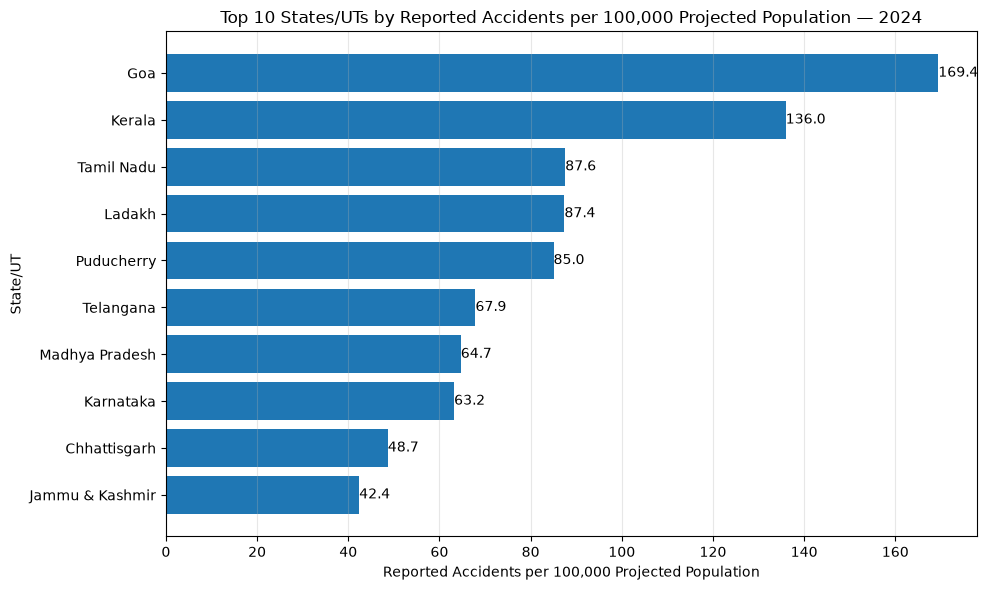

In [26]:
# Select the top 10 States/UTs by population-normalized accident rate
top_10_rate = risk_ranking.head(10).copy()

# Reverse order so the highest value appears at the top
top_10_rate = top_10_rate.iloc[::-1]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_10_rate["state"],
    top_10_rate["accidents_per_100k_population"]
)

plt.title(
    "Top 10 States/UTs by Reported Accidents per 100,000 "
    "Projected Population — 2024"
)

plt.xlabel("Reported Accidents per 100,000 Projected Population")
plt.ylabel("State/UT")

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        ha="left"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Insight — Population-Normalized Accident Burden

Population normalization produces a substantially different ranking from the
raw accident-count ranking.

Goa has the highest reported accident rate in the 2024 dataset at approximately
169.4 reported accidents per 100,000 projected population, followed by Kerala
at approximately 136.0.

This demonstrates that States/UTs with the largest absolute number of accidents
are not necessarily the States/UTs with the highest population-normalized
accident burden.

However, accidents per 100,000 projected population should not be interpreted
as a complete measure of road-accident risk because population does not capture
actual traffic exposure or travel activity.